In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv('data/train.csv')

print("Shape of dataset:", df.shape)
display(df.head())
df.info()

Shape of dataset: (1017209, 9)


C:\Users\18vic\AppData\Local\Temp\ipykernel_2852\2514732664.py:7: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/train.csv')


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [26]:

missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
if not missing.empty:
    print("\nMissing values per column:\n")
    display(missing)
else:
    print("\nNo missing values found.")


No missing values found.


In [27]:
display(df.describe().T)

print("\nData types:")
display(df.dtypes)

,count,mean,std,min,25%,50%,75%,max
Store,1017209.0,558.429727,321.908651,1.0,280.0,558.0,838.0,1115.0
DayOfWeek,1017209.0,3.998341,1.997391,1.0,2.0,4.0,6.0,7.0
Sales,1017209.0,5773.818972,3849.926175,0.0,3727.0,5744.0,7856.0,41551.0
Customers,1017209.0,633.145946,464.411734,0.0,405.0,609.0,837.0,7388.0
Open,1017209.0,0.830107,0.375539,0.0,1.0,1.0,1.0,1.0
Promo,1017209.0,0.381515,0.485759,0.0,0.0,0.0,1.0,1.0
SchoolHoliday,1017209.0,0.178647,0.383056,0.0,0.0,0.0,0.0,1.0



Data types:


Store             int64
DayOfWeek         int64
Date             object
Sales             int64
Customers         int64
Open              int64
Promo             int64
StateHoliday     object
SchoolHoliday     int64
dtype: object

In [28]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df['Day'] = df['Date'].dt.day

df.drop(columns=['Date'], inplace=True)

In [29]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

move_to_cat = ['Store', 'DayOfWeek', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']

for col in move_to_cat:
    if col in num_cols:
        num_cols.remove(col)
    if col not in cat_cols:
        cat_cols.append(col)

print(f"\n Numerical columns: {num_cols}")
print(f" Categorical columns: {cat_cols}")



 Numerical columns: ['Sales', 'Customers', 'Year', 'Month', 'Week', 'Day']
 Categorical columns: ['StateHoliday', 'Store', 'DayOfWeek', 'Open', 'Promo', 'SchoolHoliday']


In [30]:

print(f"\nCategorical columns ({len(cat_cols)}): {cat_cols}")

for col in cat_cols:
    print(f"\nValue counts for {col}:")
    display(df[col].value_counts().head(10))


Categorical columns (6): ['StateHoliday', 'Store', 'DayOfWeek', 'Open', 'Promo', 'SchoolHoliday']

Value counts for StateHoliday:


StateHoliday
0    855087
0    131072
a     20260
b      6690
c      4100
Name: count, dtype: int64


Value counts for Store:


Store
1115    942
1       942
2       942
3       942
4       942
5       942
6       942
7       942
8       942
9       942
Name: count, dtype: int64


Value counts for DayOfWeek:


...

Open
1    844392
0    172817
Name: count, dtype: int64


Value counts for Promo:


Promo
0    629129
1    388080
Name: count, dtype: int64


Value counts for SchoolHoliday:


SchoolHoliday
0    835488
1    181721
Name: count, dtype: int64

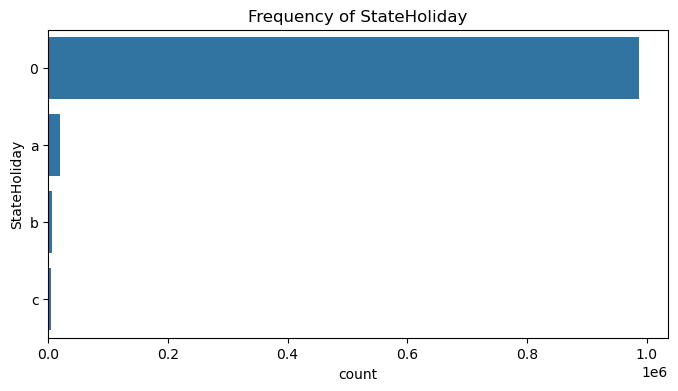

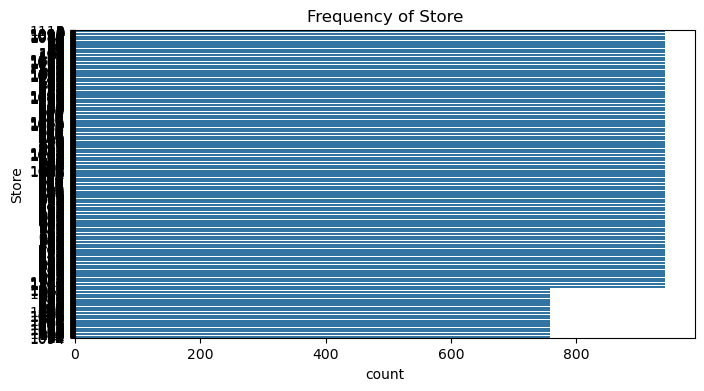

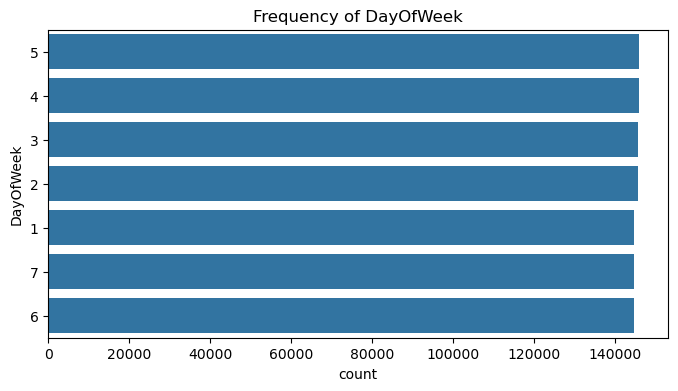

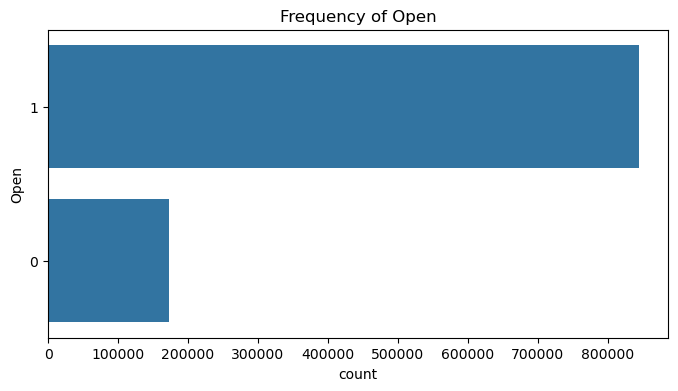

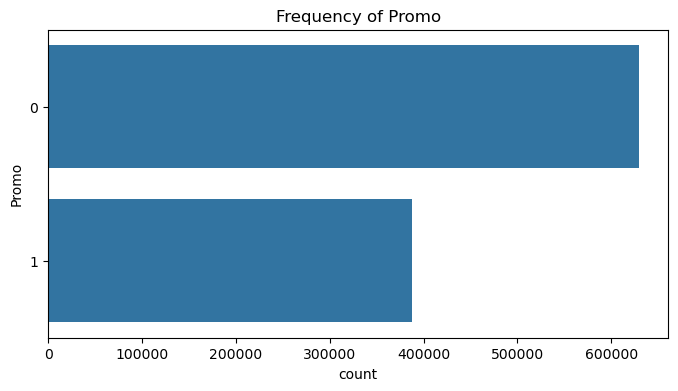

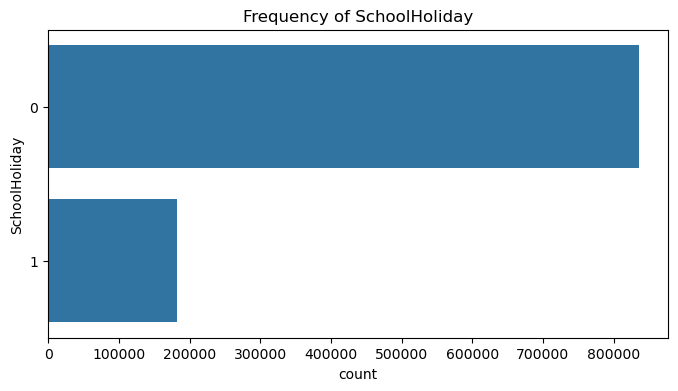

In [31]:
# Count plots for categorical features
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Frequency of {col}')
    plt.show()

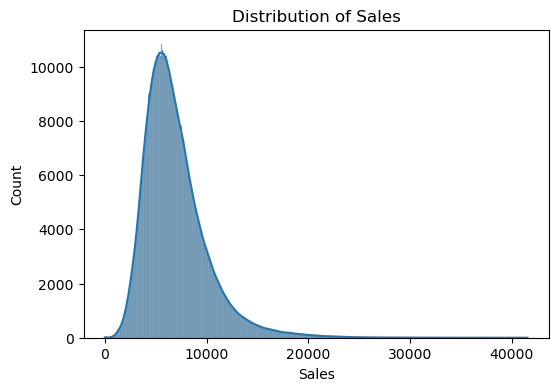

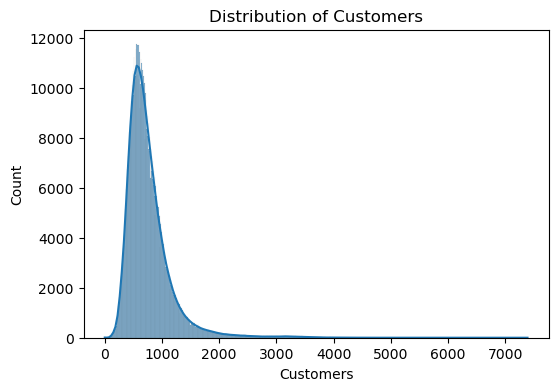

In [32]:
# Drop rows where the store was closed
df = df[df['Open'] == 1]

num_cols_plot = ["Sales", "Customers"]
# Distribution plots for numerical features
for col in num_cols_plot:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

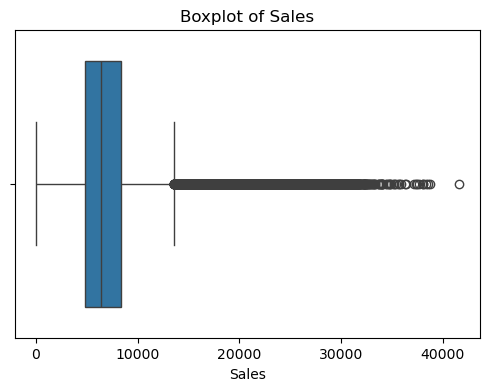

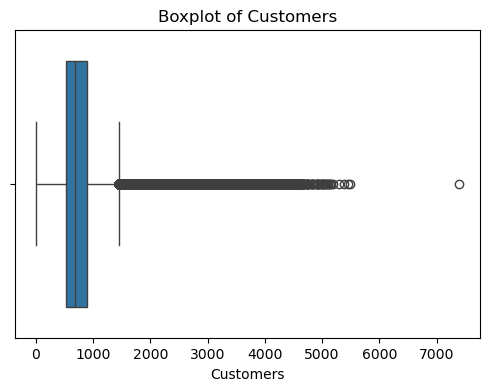

In [33]:

# Boxplots to detect outliers
for col in num_cols_plot:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


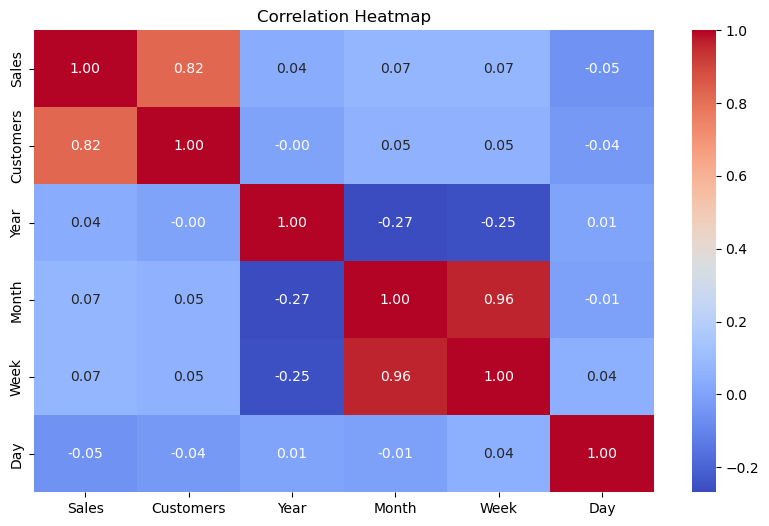

In [34]:

# Correlation Heatmap for numerical features
if len(num_cols) > 1:
    plt.figure(figsize=(10, 6))
    sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.show()


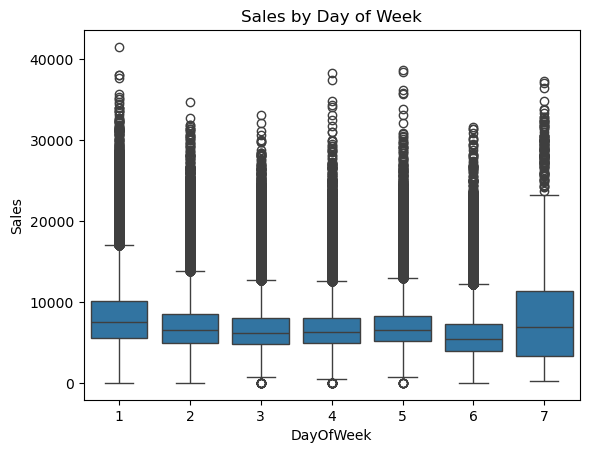

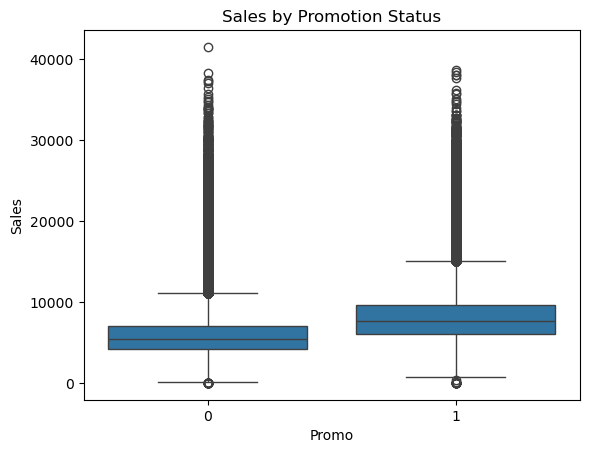

In [ ]:
sns.boxplot(x='DayOfWeek', y='Sales', data=df)
plt.title('Sales by Day of Week')
plt.show()

sns.boxplot(x='Promo', y='Sales', data=df)
plt.title('Sales by Promotion Status')
plt.show()

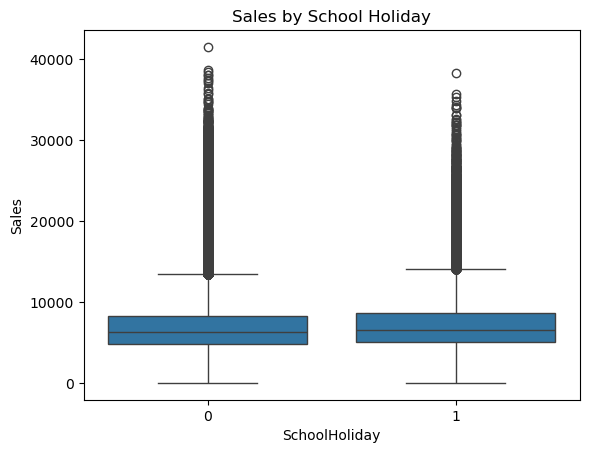

In [36]:
sns.boxplot(x='SchoolHoliday', y='Sales', data=df)
plt.title('Sales by School Holiday')
plt.show()

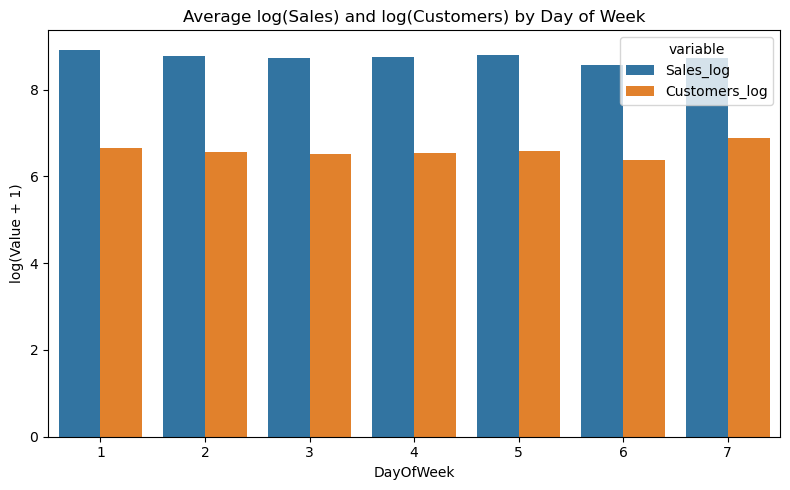

In [ ]:
# convert to log scale to reduce skewness
df['Sales_log'] = np.log1p(df['Sales'])
df['Customers_log'] = np.log1p(df['Customers'])

grouped = df.groupby('DayOfWeek')[['Sales_log', 'Customers_log']].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='DayOfWeek', y='value', hue='variable',
            data=grouped.melt(id_vars='DayOfWeek', value_vars=['Sales_log', 'Customers_log']))
plt.title('Average log(Sales) and log(Customers) by Day of Week')
plt.ylabel('log(Value)')
plt.tight_layout()
plt.show()

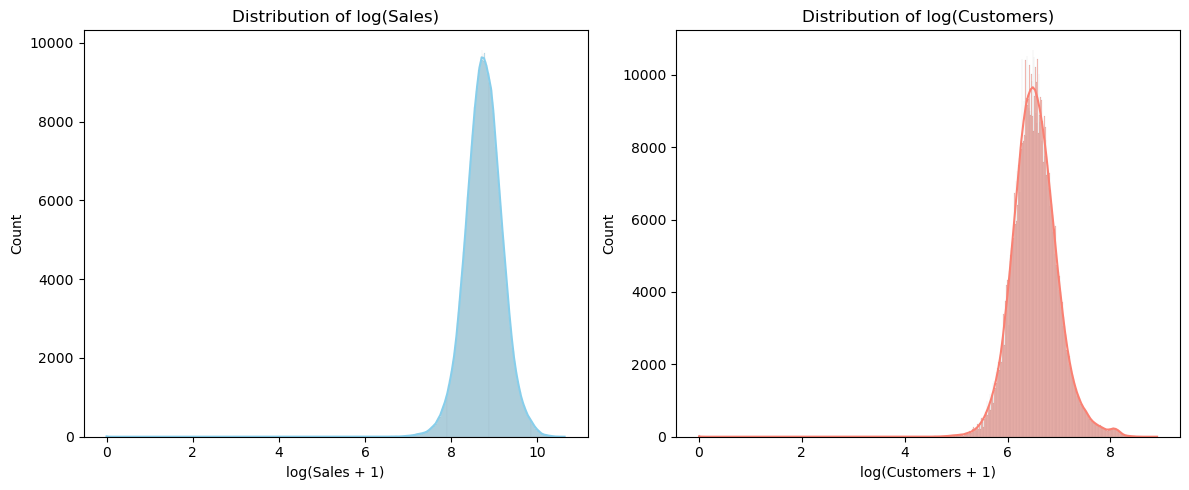

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['Sales_log'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of log(Sales)')
axes[0].set_xlabel('log(Sales)')

sns.histplot(df['Customers_log'], kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribution of log(Customers)')
axes[1].set_xlabel('log(Customers)')

plt.tight_layout()
plt.show()